In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files

uploaded = files.upload()

Saving archive (9).zip to archive (9).zip


In [4]:
import io
import zipfile

# Assuming 'archive (9).zip' is the name of your uploaded zip file
zip_file_name = list(uploaded.keys())[0]

# Read the content of the zip file
with zipfile.ZipFile(io.BytesIO(uploaded[zip_file_name]), 'r') as zf:
    # Assuming the CSV file inside is named 'House Price Prediction Dataset.csv'
    # You might need to adjust this name if it's different
    csv_file_name = 'House Price Prediction Dataset.csv'
    with zf.open(csv_file_name) as f:
        df = pd.read_csv(f)

df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [5]:
print(df.shape)

(2000, 10)


In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB
None


In [7]:
print(df.isnull().sum())

Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64


In [8]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object'):
    df[col] = le.fit_transform(df[col])

In [9]:
print(df.mean(numeric_only=True))

Id             1000.5000
Area           2786.2095
Bedrooms          3.0035
Bathrooms         2.5525
Floors            1.9935
YearBuilt      1961.4460
Location          1.4475
Condition         1.4820
Garage            0.4810
Price        537676.8550
dtype: float64


In [10]:
print(df.median(numeric_only=True))

Id             1000.5
Area           2833.0
Bedrooms          3.0
Bathrooms         3.0
Floors            2.0
YearBuilt      1961.0
Location          1.0
Condition         1.0
Garage            0.0
Price        539254.0
dtype: float64


In [11]:
print(df.mode().iloc[0])

Id                1.0
Area           4219.0
Bedrooms          1.0
Bathrooms         3.0
Floors            2.0
YearBuilt      2005.0
Location          0.0
Condition         1.0
Garage            0.0
Price        959222.0
Name: 0, dtype: float64


In [12]:
print(df.var(numeric_only=True))

Id           3.335000e+05
Area         1.677405e+06
Bedrooms     2.029503e+00
Bathrooms    1.229859e+00
Floors       6.547851e-01
YearBuilt    1.290727e+03
Location     1.290889e+00
Condition    1.268310e+00
Garage       2.497639e-01
Price        7.641291e+10
dtype: float64


In [13]:
print(df.std(numeric_only=True))

Id              577.494589
Area           1295.146799
Bedrooms          1.424606
Bathrooms         1.108990
Floors            0.809188
YearBuilt        35.926695
Location          1.136173
Condition         1.126193
Garage            0.499764
Price        276428.845719
dtype: float64


In [14]:
print(df.skew(numeric_only=True))

Id           0.000000
Area        -0.038552
Bedrooms    -0.021753
Bathrooms   -0.066546
Floors       0.011837
YearBuilt   -0.001577
Location     0.055128
Condition    0.040639
Garage       0.076112
Price       -0.064351
dtype: float64


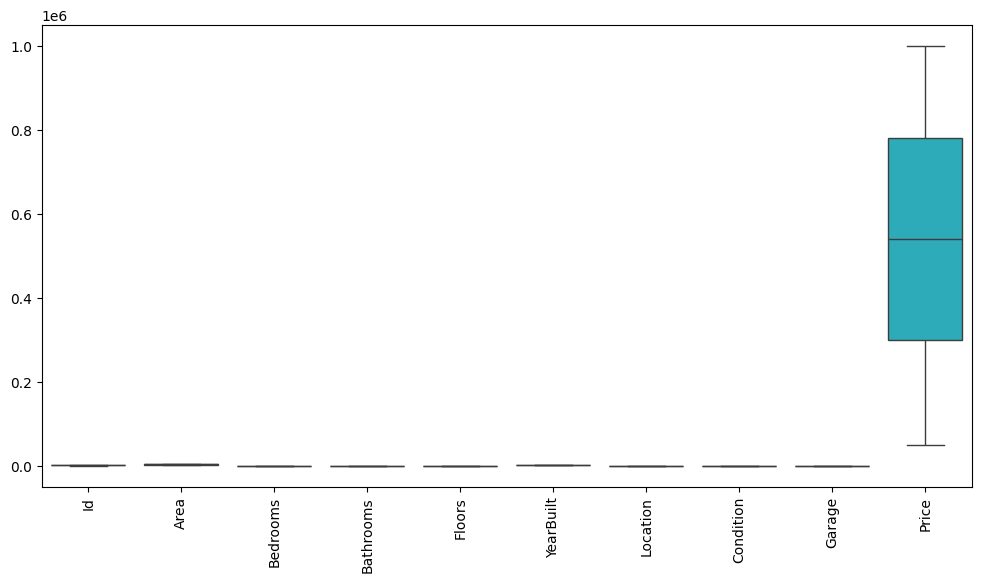

In [15]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)

plt.xticks(rotation=90)

plt.show()

In [16]:
corr = df.corr()


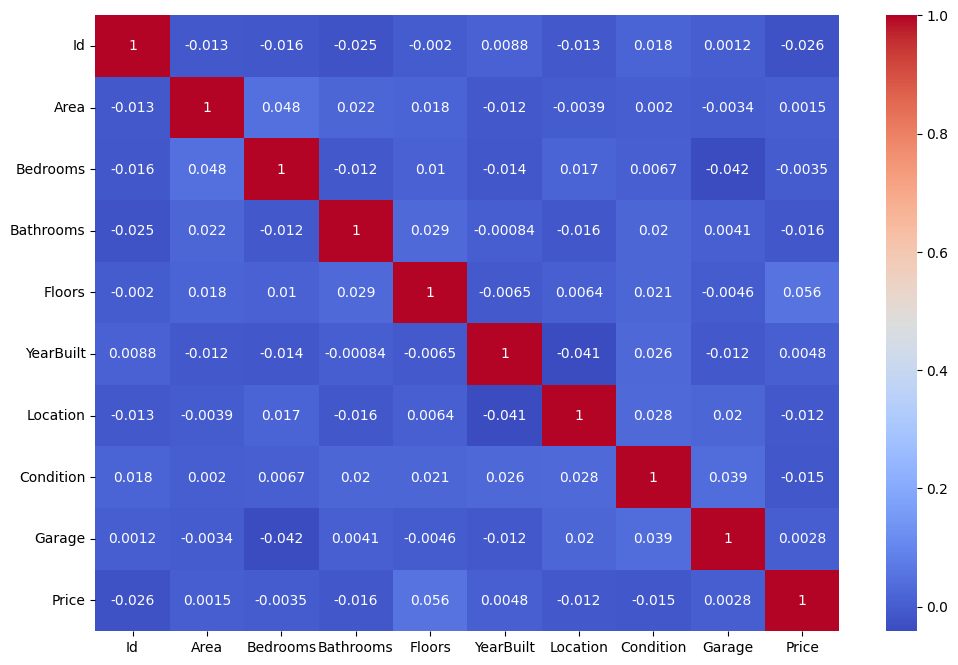

In [17]:
plt.figure(figsize=(12,8))

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm')

plt.show()

In [19]:
top_features = corr["Price"].sort_values(ascending=False)

print(top_features)

Price        1.000000
Floors       0.055890
YearBuilt    0.004845
Garage       0.002842
Area         0.001542
Bedrooms    -0.003471
Location    -0.012289
Condition   -0.015036
Bathrooms   -0.015737
Id          -0.025643
Name: Price, dtype: float64


In [21]:
X = df.drop("Price", axis=1)

y = df["Price"]

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_simple = df[["Area"]]

y = df["Price"]

Xs_train, Xs_test, ys_train, ys_test = train_test_split(
    X_simple,
    y,
    test_size=0.2,
    random_state=42
)

simple_model = LinearRegression()

simple_model.fit(Xs_train, ys_train)

LinearRegression()

In [26]:
from sklearn.metrics import mean_squared_error, r2_score

simple_pred = simple_model.predict(Xs_test)

rmse_simple = np.sqrt(mean_squared_error(ys_test, simple_pred))
r2_simple = r2_score(ys_test, simple_pred)

print("Simple RMSE:", rmse_simple)
print("Simple R2:", r2_simple)

Simple RMSE: 279027.1086887075
Simple R2: -0.0007365003351658128


In [28]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Prepare data for Multiple Linear Regression
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train Multiple Linear Regression model
multiple_model = LinearRegression()
multiple_model.fit(X_train, y_train)

# Make predictions and calculate metrics for Multiple Linear Regression
multiple_pred = multiple_model.predict(X_test)
rmse_multiple = np.sqrt(mean_squared_error(y_test, multiple_pred))
r2_multiple = r2_score(y_test, multiple_pred)

comparison = pd.DataFrame({

    "Model":["Simple Linear Regression",
             "Multiple Linear Regression"],

    "RMSE":[rmse_simple,
            rmse_multiple],

    "R2 Score":[r2_simple,
                r2_multiple]

})

print(comparison)

                        Model           RMSE  R2 Score
0    Simple Linear Regression  279027.108689 -0.000737
1  Multiple Linear Regression  280469.738028 -0.011111


In [30]:
import joblib

joblib.dump(multiple_model, "HousePricePrediction.pkl")

print("Model Saved Successfully")

Model Saved Successfully
